# Computer Vision
## Exercise Sheet 3: Image Center, Edges, Keypoints
### Erhardt Barth / Christoph Linse / Manuel Laufer / Kathleen Anderson
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{erhardt.barth, c.linse, m.laufer, k.anderson} @uni-luebeck.de*

## Note: Please insert the names of all participating students:

1. 
2. 
3. 
4. 
5. 


In [1]:
'''import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')'''

"import sys, os\nif 'google.colab' in sys.modules:\n  if os.getcwd() == '/content':\n    !git clone 'https://github.com/inb-luebeck/cs4250.git'\n    os.chdir('cs4250')"

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.morphology import dilation

%matplotlib inline

## Exercise 3.1
### Finding the Image Center
Camera calibration refers to the process of computing the intrinsic and extrinsic parameters of the camera. It is a necessary step in many computer vision applications such as 3D scene reconstruction and recognition. One important intrinsic parameter is the image center. Print out the images `ueb311.jpg` and `ueb312.jpg` and estimate the image centers by using a ruler.

**Hint**: Make small printouts of the images to have enough space around them.

In [3]:
def load_image_gray(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image

In [4]:
def load_image_gray_normalized(image_path):
    return load_image_gray(image_path).astype('float32')/255.

In [5]:
def gradient(image):
    v = .5
    k_y = np.zeros((3, 3))
    k_y[0, 1] = -v
    k_y[2, 1] = +v

    k_x = np.zeros((3, 3))
    k_x[1, 0] = -v
    k_x[1, 2] = +v

    image = np.copy(image).astype('float32')

    gradient_x = cv2.filter2D(image, -1, k_x)
    gradient_y = cv2.filter2D(image, -1, k_y)

    return gradient_x, gradient_y


## Exercise 3.2.1
### Edge Detection
Open the image `ueb32.jpg` in Python and show the image gradients $d_x$ and $d_y$. Compute the magnitude of gradients image and apply a threshold to retain only the edges of the object. For those edges, compute and show the gradient angle image (`np.arctan2`). How can you tell the angle of the gradient from looking only at the gradients?

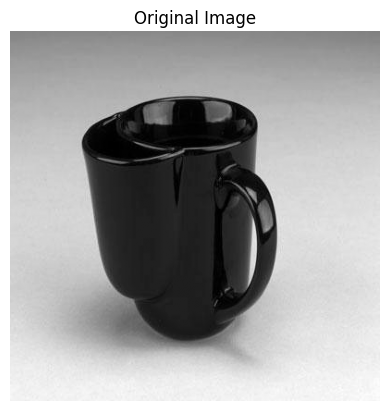

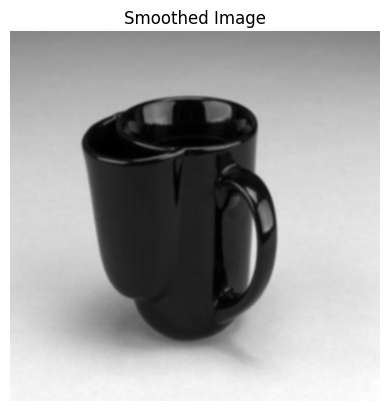

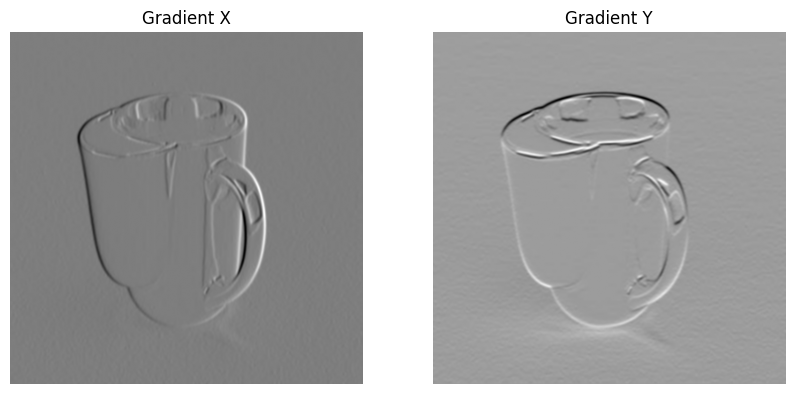

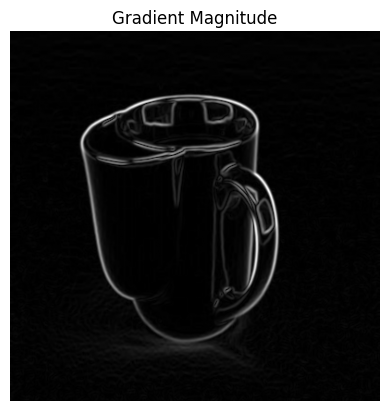

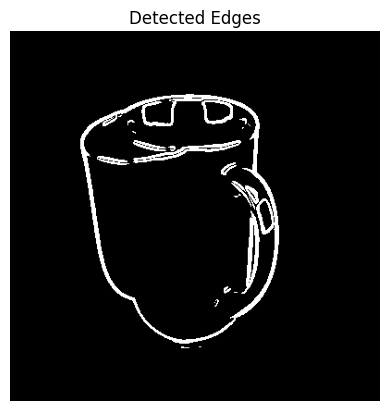

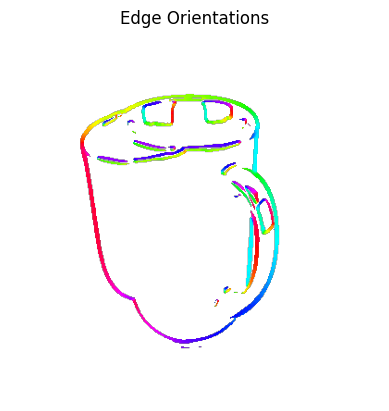

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter, sobel #



# load image
img = Image.open('data/exercise_3/ueb32.jpg').convert('L')
img = np.array(img, dtype=float)

plt.figure()
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show() #renders image on screen





# smooth image

img_smooth = gaussian_filter(img, sigma=1.0)

plt.figure()
plt.imshow(img_smooth, cmap='gray')
plt.title('Smoothed Image')
plt.axis('off')
plt.show() #render smooth image

# compute and show gradient images 
dx=sobel(img_smooth, axis=1)
dy=sobel(img_smooth, axis=0)

fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].imshow(dx, cmap='gray')
axes[0].set_title('Gradient X')
axes[0].axis('off')
axes[1].imshow(dy, cmap='gray')
axes[1].set_title('Gradient Y')
axes[1].axis('off')
plt.show()

# make images comparable

dx_norm = dx / np.max(np.abs(dx))
dy_norm = dy/ np.max(np.abs(dy))

# compute gradient magnitude
magnitude = np.sqrt(dx_norm**2 + dy_norm**2)

plt.figure()
plt.imshow(magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')
plt.show()

Threshold = 0.2 
edges = magnitude > Threshold

plt.figure()
plt.imshow(edges, cmap='gray')
plt.title('Detected Edges')
plt.axis('off')
plt.show()

# compute an angle image that should be in range [-180,+180]
angle = np.degrees(np.arctan2(dy_norm, dx_norm))


# show angles only for real edges
angle = np.where(edges, angle, np.nan)

plt.figure()
plt.imshow(angle, cmap='hsv')
plt.title('Edge Orientations')
plt.axis('off')
plt.show()





## Exercise 3.2.2
### Canny Edge Detector
Open the image `ueb32.jpg` in Python and use the OpenCV Canny algorithm to find the edges in the image.
Compare the result with the magnitude of gradient image. Display both results side by side using `plt.subplots`.
Comment on how the two results differ and why.**Furthermore, comment how the angle image and the magnitude image are used in the Canny algorithm.**

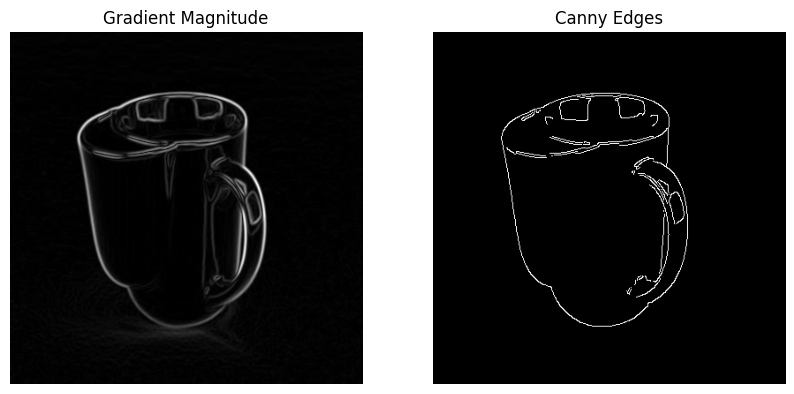

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter, sobel
import cv2



# load image
img = Image.open('data/exercise_3/ueb32.jpg').convert('L') 
img = np.array(img, dtype=float)

# compute magnitude of gradient image
img_smooth  = gaussian_filter(img, sigma=1.0)
dx = sobel(img_smooth, axis=1)
dy = sobel(img_smooth, axis=0)
magnitude = np.sqrt(dx**2 + dy**2)

# apply canny
img_uint8 = img.astype(np.uint8)
edges_canny = cv2.Canny(img_uint8, threshold1=100, threshold2=200)
# compare results

fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].imshow(magnitude, cmap='gray')
axes[0].set_title('Gradient Magnitude')
axes[0].axis('off')
axes[1].imshow(edges_canny, cmap='gray')
axes[1].set_title('Canny Edges')
axes[1].axis('off')
plt.show()

# The gradient-magnitude image shows thick, fuzzy, grayscale edges
# The Canny image showsthin binary edges
# the angle image is used for detecting the precise position of the edge
# the magnitude is used for detecting the strenght of the edge


## Exercise 3.3
### Key Point Detection
Implement the following key-point detectors:
* local maxima of $K$
* local maxima of $K$ − $\alpha$ $H^2$, with $\alpha$ as weighting parameter

The function is supposed to return images of the same size as the input, where the pixels contain $K$ or $K$ − $\alpha$ $H^2$.

$K$ and $H$ should be the invariants of the structure tensor $J$ (see script).
Evaluate the detectors above on two kinds of test images: (i) the synthetic image `ueb331.npy`, (ii) the
picture `ueb332.jpg`.

Comment your results with a focus on
1. the localization of the key points
2. the influence of the $H$ term as controlled via the parameter $\alpha$.

**Question**: Why do you filter the image with a Gaussian kernel a second time? It is **not** about noise removal!

**Hint**: Use the provided functions `find_local_max` and `plot_marks`.

In [8]:
def find_local_max(keypoints, thres=1e-6, k=3):
    kernel = np.ones((k, k))
    kernel[k//2, k//2] = 0
    local_max = keypoints > thres + dilation(keypoints, kernel)

    return local_max

In [9]:
def plot_marks(map, ax=None):
    if ax is None:
        _, ax = plt.subplots(1)
    col, row = np.nonzero(map)

    ax.plot(row, col, 'r.')

In [ ]:
def key_points_structure(image, alpha, sigma=.1):
    # image parameters
    image = image.astype(float)

    # 0. filter with Gaussian kernel with sigma
    img_smooth = gaussian_filter(image, sigma=sigma)

    # 1. partial derivatives
    Ix, Iy = gradient(img_smooth)

    # 2. product images
    dxx = Ix * Ix
    dyy = Iy * Iy
    dxy = Ix * Iy

    # 3. filter with gaussian kernel with sigma = 1
    Jxx = gaussian_filter(dxx, sigma=1)
    Jyy = gaussian_filter(dyy, sigma=1)
    Jxy = gaussian_filter(dxy, sigma=1)
    # 4. compute invarians for J

    K = Jxx * Jyy - Jxy**2  
    H = Jxx + Jyy             
    K_minus_H = K - alpha * H**2



    # return K, K_minus_H
    return K, K_minus_H
    

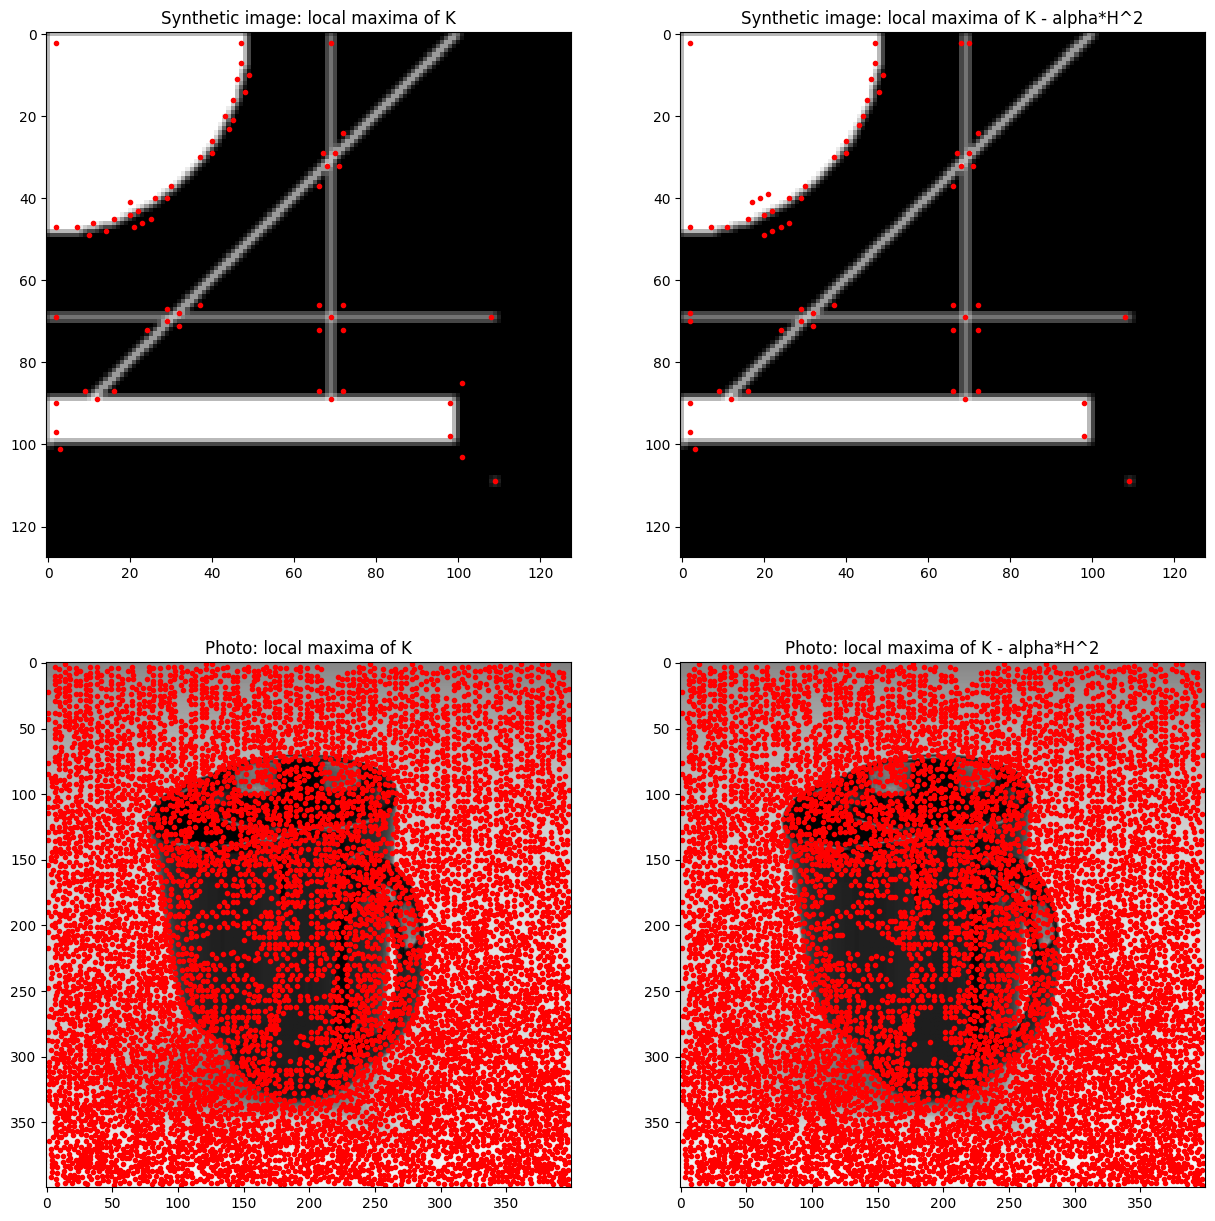

In [11]:
# define alpha, sigma, and k

alpha = 0.05
sigma = 0.1
k = 3

# load images
image1 = np.load('data/exercise_3/ueb331.npy')
image2 = np.array(Image.open('data/exercise_3/ueb332.jpg').convert('L'), dtype=float)

# extract keypoints
keypoints_K, keypoints_K_minus_H = key_points_structure(image1, alpha, sigma)

# show found keypoints (K, K_minus_H) for both images
# example
_, ax = plt.subplots(2, 2, figsize=(15, 15))
 
local_max = find_local_max(keypoints_K)
ax[0][0].imshow(image1, cmap='gray')
ax[0][0].set_title('Synthetic image: local maxima of K')
plot_marks(local_max, ax[0][0])
 
local_max = find_local_max(keypoints_K_minus_H)
ax[0][1].imshow(image1, cmap='gray')
ax[0][1].set_title('Synthetic image: local maxima of K - alpha*H^2')
plot_marks(local_max, ax[0][1])
 
keypoints_K, keypoints_K_minus_H = key_points_structure(image2, alpha, sigma)
image = image2
 
local_max = find_local_max(keypoints_K)
ax[1][0].imshow(image, cmap='gray')
ax[1][0].set_title('Photo: local maxima of K')
plot_marks(local_max, ax[1][0])
 
local_max = find_local_max(keypoints_K_minus_H)
ax[1][1].imshow(image, cmap='gray')
ax[1][1].set_title('Photo: local maxima of K - alpha*H^2')
plot_marks(local_max, ax[1][1])
 
plt.show()